# Full Causal Analysis with Three Different Datasets
1. Create the data using DoWhy and draw the DAG using my Duplo graphviz for visualisation purposes
2. Identify the estimands (different ways of understanding the causal effect given the DAG e.g. Backdoor, IV, Frontdoor)
3. Estimate the causal effect by taking one estimand using a specific sttistical method e.g. linear regression
4. Validate the results with 'REFUTATIONS' to test robustness of findings


at any point call dowhy_help() to understand what tools are available through the DoWhy library. The above is dowhy_help('workflow')

In [42]:
import sys, os
sys.path.append(os.path.abspath(".."))  # go up one level so 'blocks' is visible

import dowhy
from dowhy import CausalModel
import dowhy.datasets
import numpy as np
import pandas as pd
from blocks.draw import draw_duplo_dag, duplo_to_dot
from blocks.add_node import add_node
from blocks.utils import get_colors
from blocks.dowhy import dowhy_help

import warnings
warnings.filterwarnings('ignore')

colors = get_colors(10)

In [43]:
dowhy_help()

Available help topics:
dowhy_help('methods') - Estimation methods
dowhy_help('tests') - Refutation tests
dowhy_help('workflow') - Standard workflow steps
dowhy_help('data') - Data requirements
dowhy_help('datasets') - Synthetic data generators
dowhy_help('all') - Everything


In [3]:
dowhy_help('workflow')

=== DoWhy Workflow ===

1️⃣ CREATE MODEL:
model = CausalModel(data=df, treatment='X', outcome='Y', graph='...')

2️⃣ IDENTIFY EFFECT:
estimand = model.identify_effect()
# Shows all available identification strategies

3️⃣ ESTIMATE EFFECT:
effect = model.estimate_effect(estimand, method_name='...')
# Choose method based on your data type and assumptions

4️⃣ VALIDATE RESULTS:
refutation = model.refute_estimate(estimand, effect, method_name='...')
# Test robustness of your findings


# Dataset1: 2 common causes and an instrument

In [4]:
np.random.seed(42)
data1 = dowhy.datasets.linear_dataset(
    beta=1.5,
    num_common_causes=2,
    num_instruments=1,
    num_samples=1000,
    treatment_is_binary=False
)
print("Dataset 1 - Variables:", list(data1['df'].columns))

Dataset 1 - Variables: ['Z0', 'W0', 'W1', 'v0', 'y']


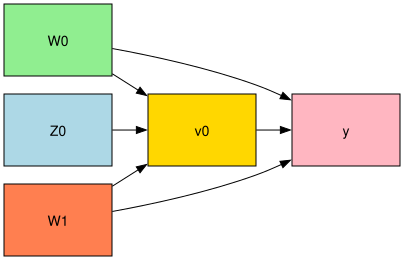

'digraph{Z0->v0; W0->v0; W0->y; W1->v0; W1->y; v0->y;}'

In [5]:
# Cell 1B: Create Duplo DAG for the same dataset
from blocks.add_node import add_node
from blocks.draw import draw_duplo_dag

nodes1 = []
add_node(nodes1, "Z0", colors[0], targets=["v0"])
add_node(nodes1, "W0", colors[1], targets=["v0", "y"])
add_node(nodes1, "W1", colors[2], targets=["v0", "y"])
add_node(nodes1, "v0", colors[3], targets=["y"])
add_node(nodes1, "y", colors[4], targets=[])
draw_duplo_dag(nodes1)

duplo_to_dot(nodes1)

In [6]:
# Create a causal model from the data and given graph by extracting the data from the dictionary that we created
model = CausalModel(
    data = data1['df'],
    treatment = data1['treatment_name'], 
    outcome = data1['outcome_name'],
    graph = data1['gml_graph']
)

In [7]:
identified_estimand = model.identify_effect()
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
  d              
─────(E[y|W0,W1])
d[v₀]            
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W0,W1,U) = P(y|v0,W0,W1)

### Estimand : 2
Estimand name: iv
Estimand expression:
 ⎡                      -1⎤
 ⎢  d      ⎛  d        ⎞  ⎥
E⎢─────(y)⋅⎜─────([v₀])⎟  ⎥
 ⎣d[Z₀]    ⎝d[Z₀]      ⎠  ⎦
Estimand assumption 1, As-if-random: If U→→y then ¬(U →→{Z0})
Estimand assumption 2, Exclusion: If we remove {Z0}→{v0}, then ¬({Z0}→y)

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
  d              
─────(E[y|W0,W1])
d[v₀]            
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W0,W1,U) = P(y|v0,W0,W1)



In [8]:
dowhy_help('methods')

=== DoWhy Estimation Methods for help estimating the effect in the model ===

📊 BACKDOOR METHODS:
• backdoor.linear_regression
  - Works with: Continuous or binary treatment
  - Best for: Linear relationships, continuous outcomes

• backdoor.propensity_score_matching
  - Works with: Binary treatment ONLY
  - Best for: Non-linear relationships, matching similar units

• backdoor.propensity_score_weighting
  - Works with: Binary treatment ONLY
  - Best for: Reweighting to balance treatment groups

• backdoor.propensity_score_stratification
  - Works with: Binary treatment ONLY
  - Best for: Subclassification analysis

🎯 INSTRUMENTAL VARIABLE METHODS:
• iv.instrumental_variable
  - Works with: Continuous or binary treatment
  - Requires: Valid instruments in your DAG
  - Best for: When unobserved confounding suspected

🚪 OTHER METHODS:
• frontdoor.two_stage_regression
  - Requires: Valid mediator variables
  - Rarely applicable in practice


In [9]:
estimate = model.estimate_effect(identified_estimand, method_name="backdoor.linear_regression")
print(estimate)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
  d              
─────(E[y|W0,W1])
d[v₀]            
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W0,W1,U) = P(y|v0,W0,W1)

## Realized estimand
b: y~v0+W0+W1
Target units: ate

## Estimate
Mean value: 1.5001047635706994



In [10]:
dowhy_help('tests')

=== DoWhy Refutation Tests ===

🔍 ROBUSTNESS TESTS:
• random_common_cause
  - Adds random confounder to test sensitivity - change should be close to 0

• placebo_treatment_refuter
  - Replaces treatment with random variable - placebo effect should be close to 0

• data_subset_refuter
  - Tests on random subsets of data - change should be close to 0

• add_unobserved_common_cause
  - Simulates unobserved confounding - change should be close to 0

🎯 USAGE:
refutation = model.refute_estimate(estimand, effect, method_name='test_name')


In [11]:
# Refutation Test 1: Add random confounder
refutation1 = model.refute_estimate(identified_estimand, estimate, 
                                   method_name="random_common_cause")
print("Random confounder test:")
print(f"Original estimate: {estimate.value:.4f}")
print(f"With random confounder: {refutation1.new_effect:.4f}")
print(f"Change: {abs(estimate.value - refutation1.new_effect):.4f}")

Random confounder test:
Original estimate: 1.5001
With random confounder: 1.5001
Change: 0.0000


In [12]:
# Test 2: Placebo treatment
refutation2 = model.refute_estimate(identified_estimand, estimate,
                                   method_name="placebo_treatment_refuter")
print("\nPlacebo treatment test:")
print(f"Original estimate: {estimate.value:.4f}")
print(f"Placebo estimate: {refutation2.new_effect:.4f}")


Placebo treatment test:
Original estimate: 1.5001
Placebo estimate: 0.0000


In [13]:
# Test 3: Data subset robustness
refutation3 = model.refute_estimate(identified_estimand, estimate,
                                   method_name="data_subset_refuter")
print("\nData subset test:")
print(f"Original estimate: {estimate.value:.4f}")
print(f"Subset estimate: {refutation3.new_effect:.4f}")
print(f"Change: {abs(estimate.value - refutation3.new_effect):.4f}")


Data subset test:
Original estimate: 1.5001
Subset estimate: 1.5001
Change: 0.0000


# Dataset2 Multiple common causes, no instruments

In [14]:
# Cell 2A: Generate data for binary treatment 
data2 = dowhy.datasets.linear_dataset(
    beta=2.0,
    num_common_causes=3,
    num_instruments=0,
    num_samples=1000,
    treatment_is_binary=True
)
print("Dataset 2 - Variables:", list(data2['df'].columns))

Dataset 2 - Variables: ['W0', 'W1', 'W2', 'v0', 'y']


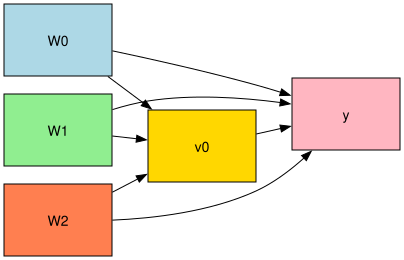

In [15]:
# Cell 2B: Create Duplo DAG
nodes2 = []
add_node(nodes2, "W0", colors[0], targets=["v0", "y"])
add_node(nodes2, "W1", colors[1], targets=["v0", "y"])
add_node(nodes2, "W2", colors[2], targets=["v0", "y"])
add_node(nodes2, "v0", colors[3], targets=["y"])
add_node(nodes2, "y", colors[4], targets=[])
draw_duplo_dag(nodes2)

In [16]:
# Create a causal model from the data and given graph by extracting the data from the dictionary that we created
model = CausalModel(
    data = data2['df'],
    treatment = data2['treatment_name'], 
    outcome = data2['outcome_name'],
    graph = data2['gml_graph']
)

In [17]:
identified_estimand = model.identify_effect()
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
  d                 
─────(E[y|W0,W2,W1])
d[v₀]               
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W0,W2,W1,U) = P(y|v0,W0,W2,W1)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
  d                 
─────(E[y|W0,W2,W1])
d[v₀]               
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W0,W2,W1,U) = P(y|v0,W0,W2,W1)



In [18]:
estimate = model.estimate_effect(identified_estimand, method_name="backdoor.linear_regression")
print(estimate)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
  d                 
─────(E[y|W0,W2,W1])
d[v₀]               
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W0,W2,W1,U) = P(y|v0,W0,W2,W1)

## Realized estimand
b: y~v0+W0+W2+W1
Target units: ate

## Estimate
Mean value: 2.000286896766286



## Let's compare this to a simple correlation between v0 and y. 
- Let's check the data first so we don't get regression errors

In [19]:
print("Data types in dataset 2:")
print(data2['df'].dtypes)
print("\nFirst few rows:")
print(data2['df'].head())

Data types in dataset 2:
W0    float64
W1    float64
W2    float64
v0       bool
y     float64
dtype: object

First few rows:
         W0        W1        W2     v0         y
0  0.660674 -2.513082  1.914958   True  1.693549
1  1.631806 -1.366855  1.935918   True  2.683361
2  0.030289 -0.143300  0.572280   True  2.041206
3  0.697593 -2.229948  1.181477  False -0.284796
4  2.294348 -0.274570 -1.110049  False  1.149034


In [20]:
from blocks.regression import regression

# Convert boolean treatment to numeric (True->1, False->0)
df_fixed = data2['df'].copy()
df_fixed['v0'] = df_fixed['v0'].astype(int)

# Now run your regressions
naive_model = regression(df_fixed, x='v0', y='y', controls=[])
naive_coef = naive_model.params['v0']

In [21]:
print(naive_coef)

2.605693222936262


In [22]:
# Refutation Test 1: Add random confounder
refutation1 = model.refute_estimate(identified_estimand, estimate, 
                                   method_name="random_common_cause")
print("Random confounder test:")
print(f"Original estimate: {estimate.value:.4f}")
print(f"With random confounder: {refutation1.new_effect:.4f}")
print(f"Change: {abs(estimate.value - refutation1.new_effect):.4f}")

Random confounder test:
Original estimate: 2.0003
With random confounder: 2.0003
Change: 0.0000


In [23]:
# Test 2: Placebo treatment
refutation2 = model.refute_estimate(identified_estimand, estimate,
                                   method_name="placebo_treatment_refuter")
print("\nPlacebo treatment test:")
print(f"Original estimate: {estimate.value:.4f}")
print(f"Placebo estimate: {refutation2.new_effect:.4f}")


Placebo treatment test:
Original estimate: 2.0003
Placebo estimate: 0.0078


In [24]:
# Test 3: Data subset robustness
refutation3 = model.refute_estimate(identified_estimand, estimate,
                                   method_name="data_subset_refuter")
print("\nData subset test:")
print(f"Original estimate: {estimate.value:.4f}")
print(f"Subset estimate: {refutation3.new_effect:.4f}")
print(f"Change: {abs(estimate.value - refutation3.new_effect):.4f}")


Data subset test:
Original estimate: 2.0003
Subset estimate: 2.0002
Change: 0.0000


# Dataset3 Multiple instruments

In [25]:
# Cell 3A: Generate data
data3 = dowhy.datasets.linear_dataset(
    beta=0.8,
    num_common_causes=1,
    num_instruments=3,
    num_samples=1000,
    treatment_is_binary=True
)
print("Dataset 3 - Variables:", list(data3['df'].columns))

Dataset 3 - Variables: ['Z0', 'Z1', 'Z2', 'W0', 'v0', 'y']


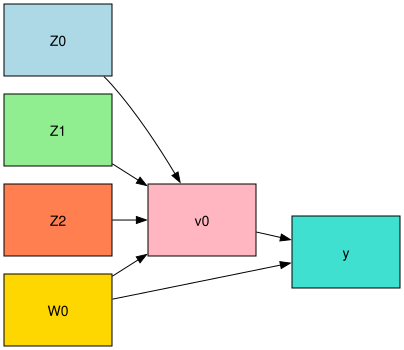

In [26]:
# Cell 3B: Create Duplo DAG
nodes3 = []
add_node(nodes3, "Z0", colors[0], targets=["v0"])
add_node(nodes3, "Z1", colors[1], targets=["v0"])
add_node(nodes3, "Z2", colors[2], targets=["v0"])
add_node(nodes3, "W0", colors[3], targets=["v0", "y"])
add_node(nodes3, "v0", colors[4], targets=["y"])
add_node(nodes3, "y", colors[5], targets=[])
draw_duplo_dag(nodes3)

In [27]:
dowhy_help('workflow')

=== DoWhy Workflow ===

1️⃣ CREATE MODEL:
model = CausalModel(data=df, treatment='X', outcome='Y', graph='...')

2️⃣ IDENTIFY EFFECT:
estimand = model.identify_effect()
# Shows all available identification strategies

3️⃣ ESTIMATE EFFECT:
effect = model.estimate_effect(estimand, method_name='...')
# Choose method based on your data type and assumptions

4️⃣ VALIDATE RESULTS:
refutation = model.refute_estimate(estimand, effect, method_name='...')
# Test robustness of your findings


In [28]:
# Create a causal model from the data and given graph by extracting the data from the dictionary that we created
model = CausalModel(
    data = data3['df'],
    treatment = data3['treatment_name'], 
    outcome = data3['outcome_name'],
    graph = data3['gml_graph']
)

In [29]:
estimand = model.identify_effect()
print(estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
  d           
─────(E[y|W0])
d[v₀]         
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W0,U) = P(y|v0,W0)

### Estimand : 2
Estimand name: iv
Estimand expression:
 ⎡                                      -1⎤
 ⎢      d          ⎛      d            ⎞  ⎥
E⎢─────────────(y)⋅⎜─────────────([v₀])⎟  ⎥
 ⎣d[Z₀  Z₁  Z₂]    ⎝d[Z₀  Z₁  Z₂]      ⎠  ⎦
Estimand assumption 1, As-if-random: If U→→y then ¬(U →→{Z0,Z1,Z2})
Estimand assumption 2, Exclusion: If we remove {Z0,Z1,Z2}→{v0}, then ¬({Z0,Z1,Z2}→y)

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
  d           
─────(E[y|W0])
d[v₀]         
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W0,U) = P(y|v0,W0)



In [30]:
dowhy_help('methods')

=== DoWhy Estimation Methods for help estimating the effect in the model ===

📊 BACKDOOR METHODS:
• backdoor.linear_regression
  - Works with: Continuous or binary treatment
  - Best for: Linear relationships, continuous outcomes

• backdoor.propensity_score_matching
  - Works with: Binary treatment ONLY
  - Best for: Non-linear relationships, matching similar units

• backdoor.propensity_score_weighting
  - Works with: Binary treatment ONLY
  - Best for: Reweighting to balance treatment groups

• backdoor.propensity_score_stratification
  - Works with: Binary treatment ONLY
  - Best for: Subclassification analysis

🎯 INSTRUMENTAL VARIABLE METHODS:
• iv.instrumental_variable
  - Works with: Continuous or binary treatment
  - Requires: Valid instruments in your DAG
  - Best for: When unobserved confounding suspected

🚪 OTHER METHODS:
• frontdoor.two_stage_regression
  - Requires: Valid mediator variables
  - Rarely applicable in practice


In [37]:
effect = model.estimate_effect(estimand, method_name='backdoor.linear_regression')
print(effect)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
  d           
─────(E[y|W0])
d[v₀]         
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W0,U) = P(y|v0,W0)

## Realized estimand
b: y~v0+W0
Target units: ate

## Estimate
Mean value: 0.7994262431912764



In [32]:
effect = model.estimate_effect(estimand, method_name='iv.instrumental_variable')
print(effect)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: iv
Estimand expression:
 ⎡                                      -1⎤
 ⎢      d          ⎛      d            ⎞  ⎥
E⎢─────────────(y)⋅⎜─────────────([v₀])⎟  ⎥
 ⎣d[Z₀  Z₁  Z₂]    ⎝d[Z₀  Z₁  Z₂]      ⎠  ⎦
Estimand assumption 1, As-if-random: If U→→y then ¬(U →→{Z0,Z1,Z2})
Estimand assumption 2, Exclusion: If we remove {Z0,Z1,Z2}→{v0}, then ¬({Z0,Z1,Z2}→y)

## Realized estimand
Realized estimand: Wald Estimator
Realized estimand type: EstimandType.NONPARAMETRIC_ATE
Estimand expression:
 ⎡    d       ⎤ 
E⎢─────────(y)⎥ 
 ⎣dZ0,Z1,Z2   ⎦ 
────────────────
 ⎡    d        ⎤
E⎢─────────(v₀)⎥
 ⎣dZ0,Z1,Z2    ⎦
Estimand assumption 1, As-if-random: If U→→y then ¬(U →→{Z0,Z1,Z2})
Estimand assumption 2, Exclusion: If we remove {Z0,Z1,Z2}→{v0}, then ¬({Z0,Z1,Z2}→y)
Estimand assumption 3, treatment_effect_homogeneity: Each unit's treatment ['v0'] is affected in the same way by com

## Interesting, we have two different effects, one for backdoor controlling and the other for IV
- Backdoor more likely to be correct as it's more reliable than IV
- This is in fact the case if you look back at how the synthetic data was created

In [41]:
# Refutation Test 1: Add random confounder
refutation1 = model.refute_estimate(estimand, estimate, 
                                   method_name="random_common_cause")
print("Random confounder test:")
print(f"Original estimate: {effect.value:.4f}")
print(f"With random confounder: {refutation1.new_effect:.4f}")
print(f"Change: {abs(effect.value - refutation1.new_effect):.4f}")

Random confounder test:
Original estimate: 0.7994
With random confounder: 0.7994
Change: 0.0000


In [40]:
# Test 2: Data subset robustness
refutation3 = model.refute_estimate(estimand, estimate,
                                   method_name="data_subset_refuter")
print("\nData subset test:")
print(f"Original estimate: {effect.value:.4f}")
print(f"Subset estimate: {refutation3.new_effect:.4f}")
print(f"Change: {abs(estimate.value - refutation3.new_effect):.4f}")


Data subset test:
Original estimate: 0.7994
Subset estimate: 0.7994
Change: 0.0000
